# PROJECT TITLE  : Netflix Content Analysis & Visualization Dashboard
# INTERN         : Karthik Neduri
# COMPANY        : Horizon TechX
# DOMAIN         : AI & Data Science
# FACULTY GUIDE  : Vani Prasanna
# DATASET        : Netflix Movies and TV Shows (Kaggle)
# SOURCE         : https://www.kaggle.com/shivamb/netflix-shows

In [ ]:
# --- Core Libraries ---
import pandas as pd
import numpy as np
from datetime import datetime

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Utility ---
import warnings
warnings.filterwarnings('ignore')

# --- Plotting Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['font.family'] = 'sans-serif'

# --- Netflix Brand Colors ---
NETFLIX_RED = '#E50914'
NETFLIX_BLACK = '#221F1F'
NETFLIX_DARK = '#F5F5F1'
COLOR_MOVIES = '#B81D24'
COLOR_TVSHOWS = '#F5F5F1'
PALETTE = ['#E50914', '#B81D24', '#831A1D', '#4A1516', '#221F1F',
           '#FF6B6B', '#C0392B', '#E74C3C', '#F1948A', '#FADBD8']

print("=" * 60)
print("✅ ALL LIBRARIES LOADED SUCCESSFULLY")
print("=" * 60)

✅ ALL LIBRARIES LOADED SUCCESSFULLY


#2: LOAD DATASET

In [ ]:
df = pd.read_csv('netflix_titles.csv')

print("=" * 60)
print("✅ DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"   📊 Rows    : {df.shape[0]:,}")
print(f"   📊 Columns : {df.shape[1]}")
print(f"   📊 Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ DATASET LOADED SUCCESSFULLY
   📊 Rows    : 8,807
   📊 Columns : 12
   📊 Memory  : 7.79 MB


#3: COLUMN OVERVIEW

In [ ]:
print("=" * 60)
print("📋 COLUMN INFORMATION")
print("=" * 60)

col_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Null Percentage': round((df.isnull().sum() / len(df)) * 100, 2).values,
    'Unique Values': df.nunique().values
})

print(col_info.to_string(index=False))

📋 COLUMN INFORMATION
 Column Name Data Type  Non-Null Count  Null Count  Null Percentage  Unique Values
     show_id    object            8807           0             0.00           8807
        type    object            8807           0             0.00              2
       title    object            8807           0             0.00           8804
    director    object            6173        2634            29.91           4528
        cast    object            7982         825             9.37           7692
     country    object            7976         831             9.44            748
  date_added    object            8797          10             0.11           1767
release_year     int64            8807           0             0.00             74
      rating    object            8803           4             0.05             17
    duration    object            8804           3             0.03            220
   listed_in    object            8807           0             0.0

#4: Missing Values Analysis

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

# Show only columns with missing values
missing_df_filtered = missing_df[missing_df['Missing Count'] > 0]

print(missing_df_filtered.to_string())
print(f"\n Total Missing Values : {df.isnull().sum().sum():,}")
print(f" Total Cells          : {df.shape[0] * df.shape[1]:,}")
print(f" Missing Percentage   : {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")


            Missing Count  Missing Percentage (%)
director             2634                   29.91
country               831                    9.44
cast                  825                    9.37
date_added             10                    0.11
rating                  4                    0.05
duration                3                    0.03

 Total Missing Values : 4,307
 Total Cells          : 105,684
 Missing Percentage   : 4.08%


#5: DATA CLEANING & PREPROCESSING

In [ ]:
df_clean = df.copy()

#5.1: Handle Missing Values

In [ ]:
print("\n Handling Missing Values...")

# 'director' — Fill with 'Unknown'
df_clean['director'].fillna('Unknown', inplace=True)

# 'cast' — Fill with 'Not Available'
df_clean['cast'].fillna('Not Available', inplace=True)

# 'country' — Fill with 'Unknown'
df_clean['country'].fillna('Unknown', inplace=True)

# 'date_added' — Drop rows with missing date_added
df_clean.dropna(subset=['date_added'], inplace=True)

# 'rating' — Fill with mode (most common rating)
df_clean['rating'].fillna(df_clean['rating'].mode()[0], inplace=True)

# 'duration' — Fill with 'Unknown'
df_clean['duration'].fillna('Unknown', inplace=True)

print(f"    Missing values handled")
print(f"    Remaining nulls: {df_clean.isnull().sum().sum()}")



 Handling Missing Values...
    Missing values handled
    Remaining nulls: 0


#5.2: Convert date_added to datetime

In [ ]:
print("\n Converting date_added to datetime...")
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], format='mixed', dayfirst=False)


 Converting date_added to datetime...


# 5.3: Extract Date Components

In [ ]:
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['month_name'] = df_clean['date_added'].dt.strftime('%B')
df_clean['day_added'] = df_clean['date_added'].dt.day

#5.4: Clean Duration Column

In [ ]:
print(" Extracting numeric duration...")

def extract_duration(row):
    if row['type'] == 'Movie':
        try:
            return int(row['duration'].replace(' min', ''))
        except:
            return None
    elif row['type'] == 'TV Show':
        try:
            return int(row['duration'].replace(' Seasons', '').replace(' Season', ''))
        except:
            return None
    return None

df_clean['duration_numeric'] = df_clean.apply(extract_duration, axis=1)

 Extracting numeric duration...


#5.5: Separate Primary Genre

In [ ]:
df_clean['primary_genre'] = df_clean['listed_in'].apply(
    lambda x: x.split(',')[0].strip() if pd.notna(x) else 'Unknown'
)

#5.6: Separate Primary Country

In [ ]:
df_clean['primary_country'] = df_clean['country'].apply(
    lambda x: x.split(',')[0].strip() if pd.notna(x) else 'Unknown'
)

#5.7: Count Genres per Title

In [ ]:
df_clean['genre_count'] = df_clean['listed_in'].apply(
    lambda x: len(x.split(',')) if pd.notna(x) else 0
)

#5.8: Verify Cleaning

In [ ]:
print("\n" + "=" * 60)
print("✅ DATA CLEANING COMPLETE")
print("=" * 60)
print(f"   📊 Original Shape : {df.shape}")
print(f"   📊 Cleaned Shape  : {df_clean.shape}")
print(f"   📊 Rows Removed   : {df.shape[0] - df_clean.shape[0]}")
print(f"   📊 Null Values    : {df_clean.isnull().sum().sum()}")


✅ DATA CLEANING COMPLETE
   📊 Original Shape : (8807, 12)
   📊 Cleaned Shape  : (8797, 20)
   📊 Rows Removed   : 10
   📊 Null Values    : 3


#6: CLEANED DATA SUMMARY

In [ ]:
print(f"\n🎬 Total Titles        : {len(df_clean):,}")
print(f"   ├─ Movies           : {len(df_clean[df_clean['type'] == 'Movie']):,}")
print(f"   └─ TV Shows         : {len(df_clean[df_clean['type'] == 'TV Show']):,}")
print(f"\n📅 Date Range Added    : {df_clean['date_added'].min().strftime('%B %d, %Y')} → {df_clean['date_added'].max().strftime('%B %d, %Y')}")
print(f"📅 Release Year Range  : {df_clean['release_year'].min()} → {df_clean['release_year'].max()}")
print(f"\n🌍 Countries           : {df_clean['primary_country'].nunique()}")
print(f"🎭 Primary Genres      : {df_clean['primary_genre'].nunique()}")
print(f"👨‍💼 Directors           : {df_clean['director'].nunique()}")
print(f"⭐ Ratings             : {df_clean['rating'].nunique()}")


🎬 Total Titles        : 8,797
   ├─ Movies           : 6,131
   └─ TV Shows         : 2,666

📅 Date Range Added    : January 01, 2008 → September 25, 2021
📅 Release Year Range  : 1925 → 2021

🌍 Countries           : 87
🎭 Primary Genres      : 36
👨‍💼 Directors           : 4529
⭐ Ratings             : 17


#6.1: FIX REMAINING NULL VALUES

In [ ]:
# Shows rows with null duration_numeric
null_dur = df_clean[df_clean['duration_numeric'].isnull()]
print(f"\n Rows with null duration_numeric: {len(null_dur)}")
print(null_dur[['title', 'type', 'duration']].to_string(index=False))

# Fill with 0 (these are 'Unknown' entries)
df_clean['duration_numeric'].fillna(0, inplace=True)

print(f"\n Remaining nulls: {df_clean.isnull().sum().sum()}")


 Rows with null duration_numeric: 3
                               title  type duration
                     Louis C.K. 2017 Movie  Unknown
               Louis C.K.: Hilarious Movie  Unknown
Louis C.K.: Live at the Comedy Store Movie  Unknown

 Remaining nulls: 0


#7: VISUALIZATION 1 — CONTENT DISTRIBUTION (MOVIES VS TV SHOWS)

#7.1: DONUT CHART — MOVIES VS TV SHOWS

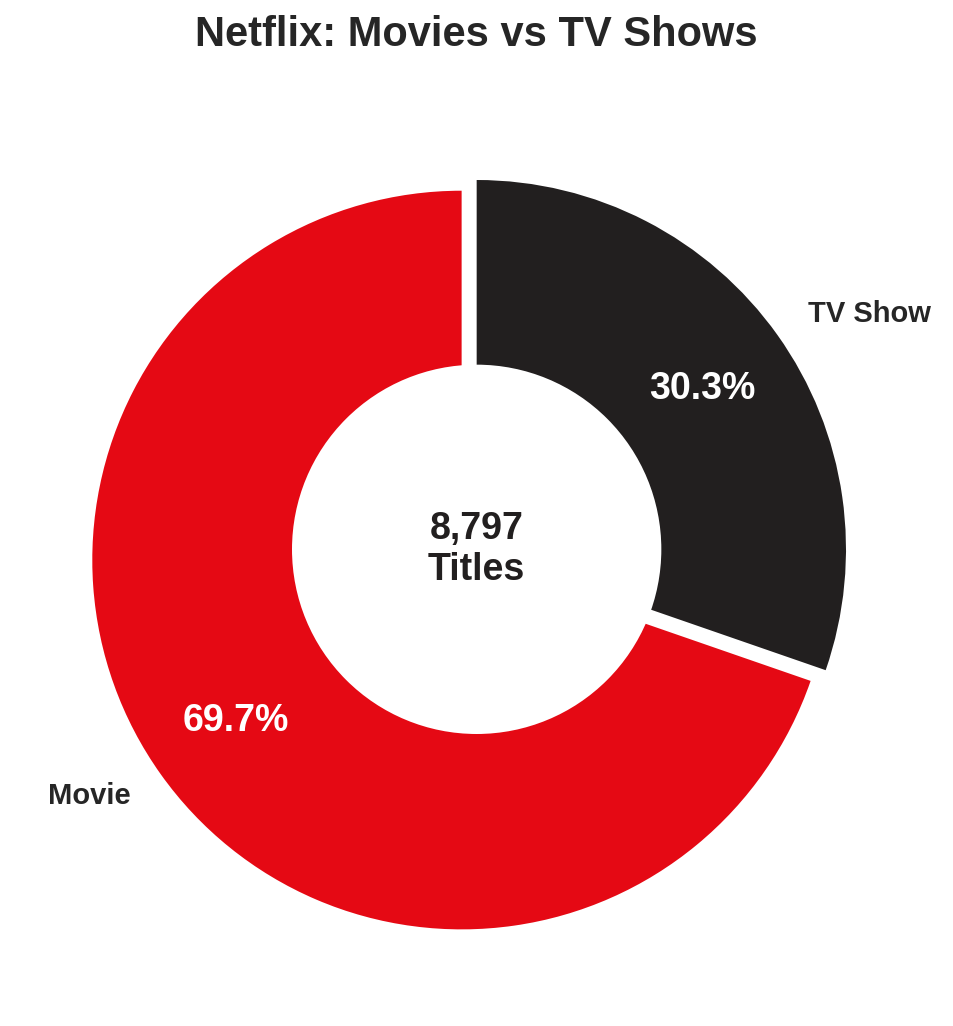

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

type_counts = df_clean['type'].value_counts()
colors = [NETFLIX_RED, '#221F1F']
explode = (0.05, 0)

wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(18)
    autotext.set_fontweight('bold')

centre_circle = plt.Circle((0, 0), 0.50, fc='white')
ax.add_artist(centre_circle)

ax.text(0, 0, f'{len(df_clean):,}\nTitles',
        ha='center', va='center', fontsize=18, fontweight='bold', color=NETFLIX_BLACK)

ax.set_title('Netflix: Movies vs TV Shows', fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('01a_donut_content_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#7.2: Count Bar Chart

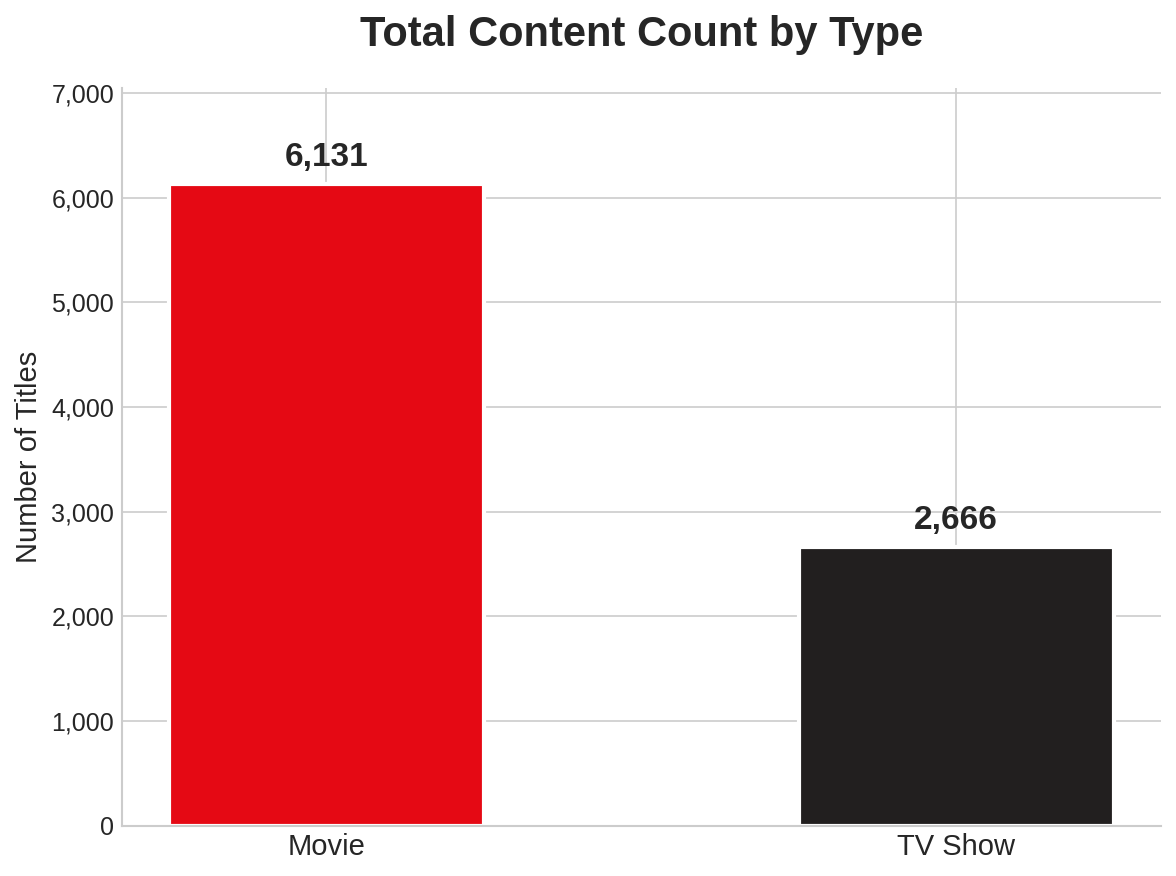

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

type_counts = df_clean['type'].value_counts()
colors = [NETFLIX_RED, '#221F1F']

bars = ax.bar(type_counts.index, type_counts.values, color=colors, edgecolor='white', linewidth=2, width=0.5)

for bar, count in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=16, fontweight='bold')

ax.set_title('Total Content Count by Type', fontsize=20, fontweight='bold', pad=20)
ax.set_ylabel('Number of Titles', fontsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_ylim(0, max(type_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('01b_bar_content_count.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#8: VISUALIZATION 2: Top 10 Countries Producing Netflix Content

#8.1: TOP 10 COUNTRIES PRODUCING NETFLIX CONTENT

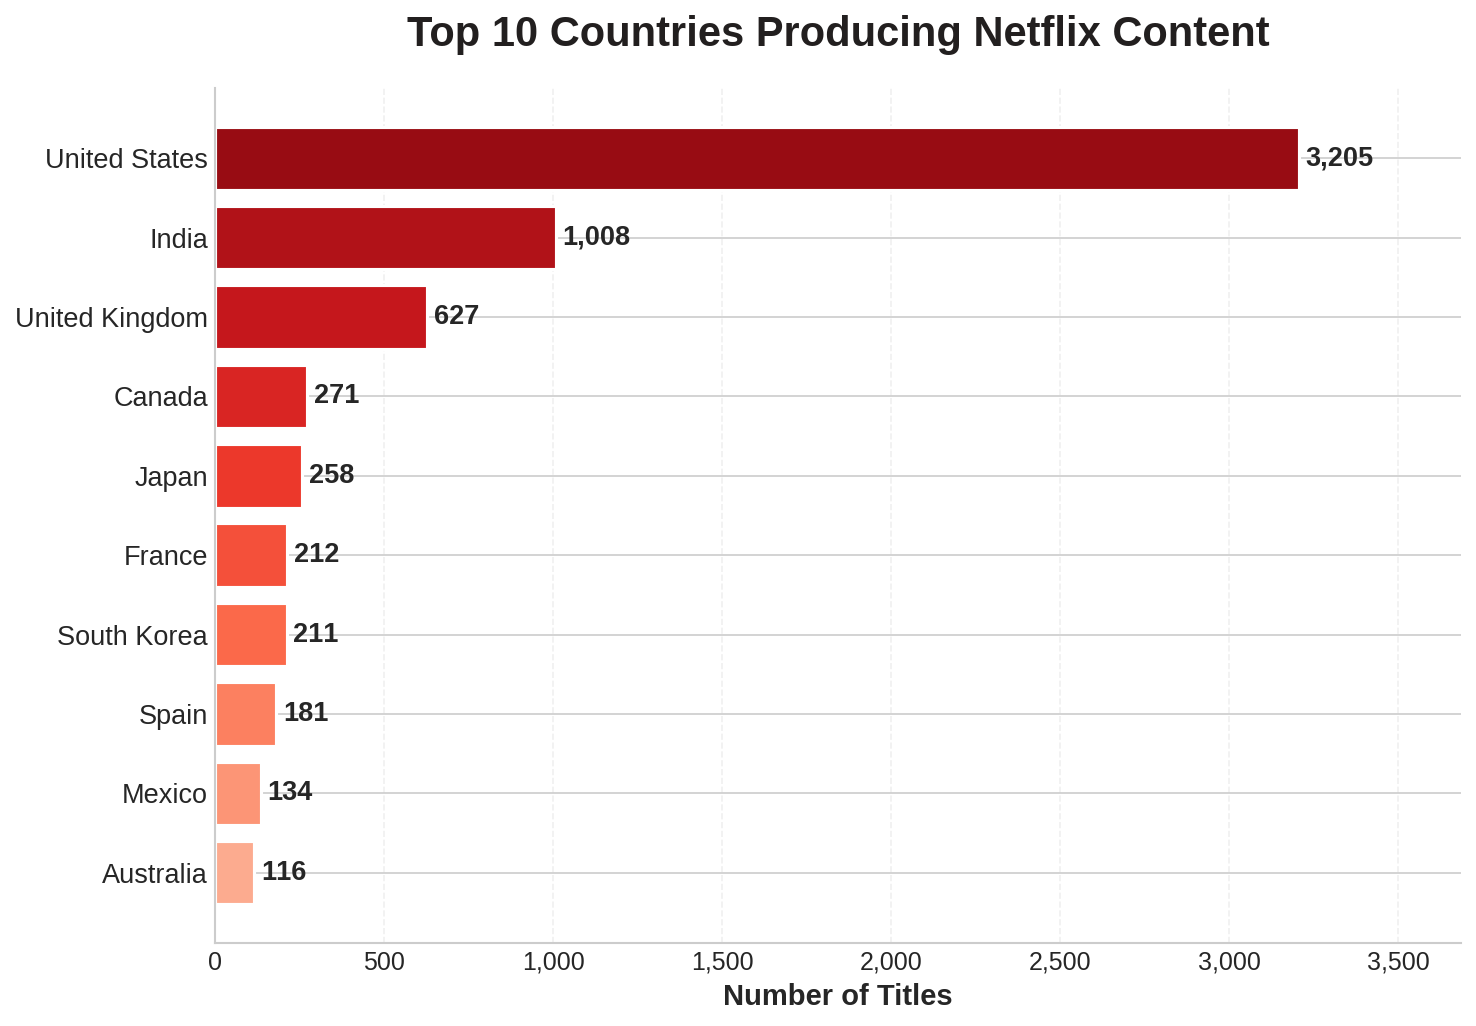


📊 Top 10 Countries:
    1. United States             → 3,205 titles
    2. India                     → 1,008 titles
    3. United Kingdom            → 627 titles
    4. Canada                    → 271 titles
    5. Japan                     → 258 titles
    6. France                    → 212 titles
    7. South Korea               → 211 titles
    8. Spain                     → 181 titles
    9. Mexico                    → 134 titles
   10. Australia                 → 116 titles


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# Count titles by primary country (excluding 'Unknown')
country_counts = df_clean[df_clean['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)

# Sort for horizontal bar chart (highest at top)
country_counts = country_counts.sort_values(ascending=True)

# Create color gradient from light to dark red
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(country_counts)))

bars = ax.barh(country_counts.index, country_counts.values, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, count in zip(bars, country_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{count:,}', ha='left', va='center', fontsize=13, fontweight='bold')

ax.set_title('Top 10 Countries Producing Netflix Content', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Number of Titles', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_xlim(0, max(country_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid for readability
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('02_top_countries.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


print(f"\n📊 Top 10 Countries:")
for i, (country, count) in enumerate(country_counts.sort_values(ascending=False).items(), 1):
    print(f"   {i:2d}. {country:<25s} → {count:,} titles")

#8.2: TOP 10 COUNTRIES — PIE CHART

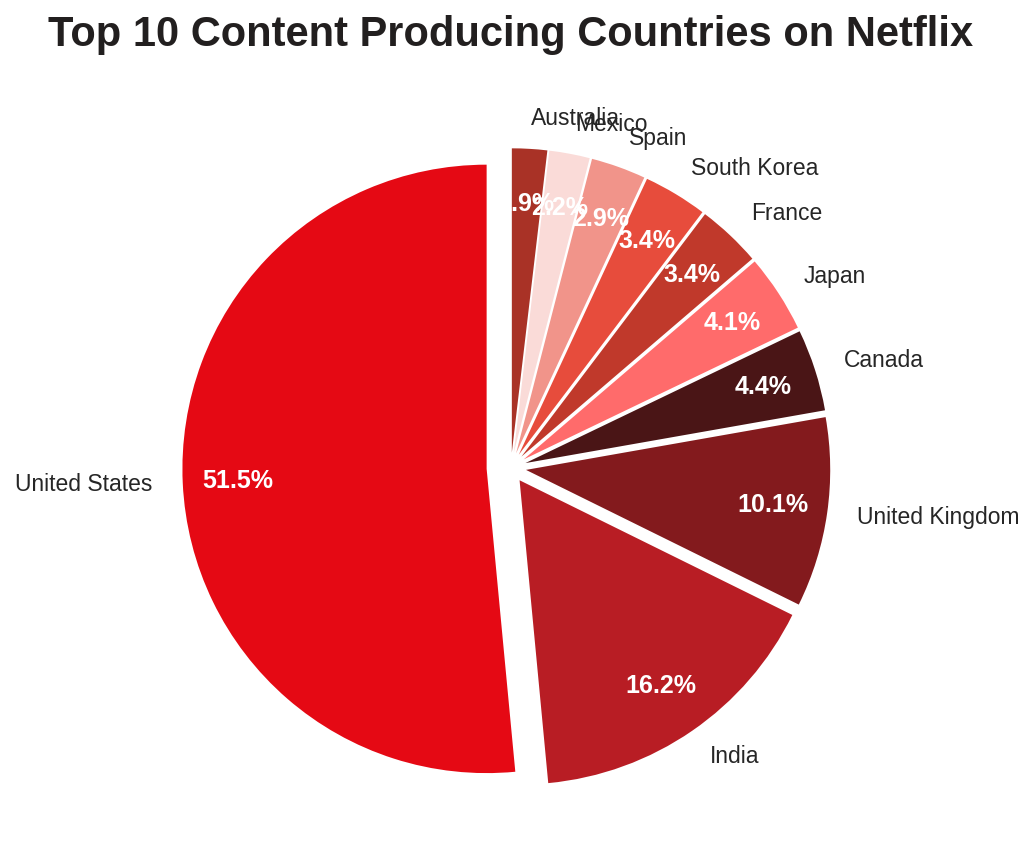

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

# Count titles by primary country (excluding 'Unknown')
country_counts = df_clean[df_clean['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)

colors = ['#E50914', '#B81D24', '#831A1D', '#4A1516', '#FF6B6B',
          '#C0392B', '#E74C3C', '#F1948A', '#FADBD8', '#A93226']

explode = [0.05] * len(country_counts)
explode[0] = 0.08

wedges, texts, autotexts = ax.pie(
    country_counts.values,
    labels=country_counts.index,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Top 10 Content Producing Countries on Netflix', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)

plt.tight_layout()
plt.savefig('02b_top_countries_pie.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#9: VISUALIZATION 3: Yearly Content Addition Trend

#9.1: YEARLY CONTENT ADDITION TREND

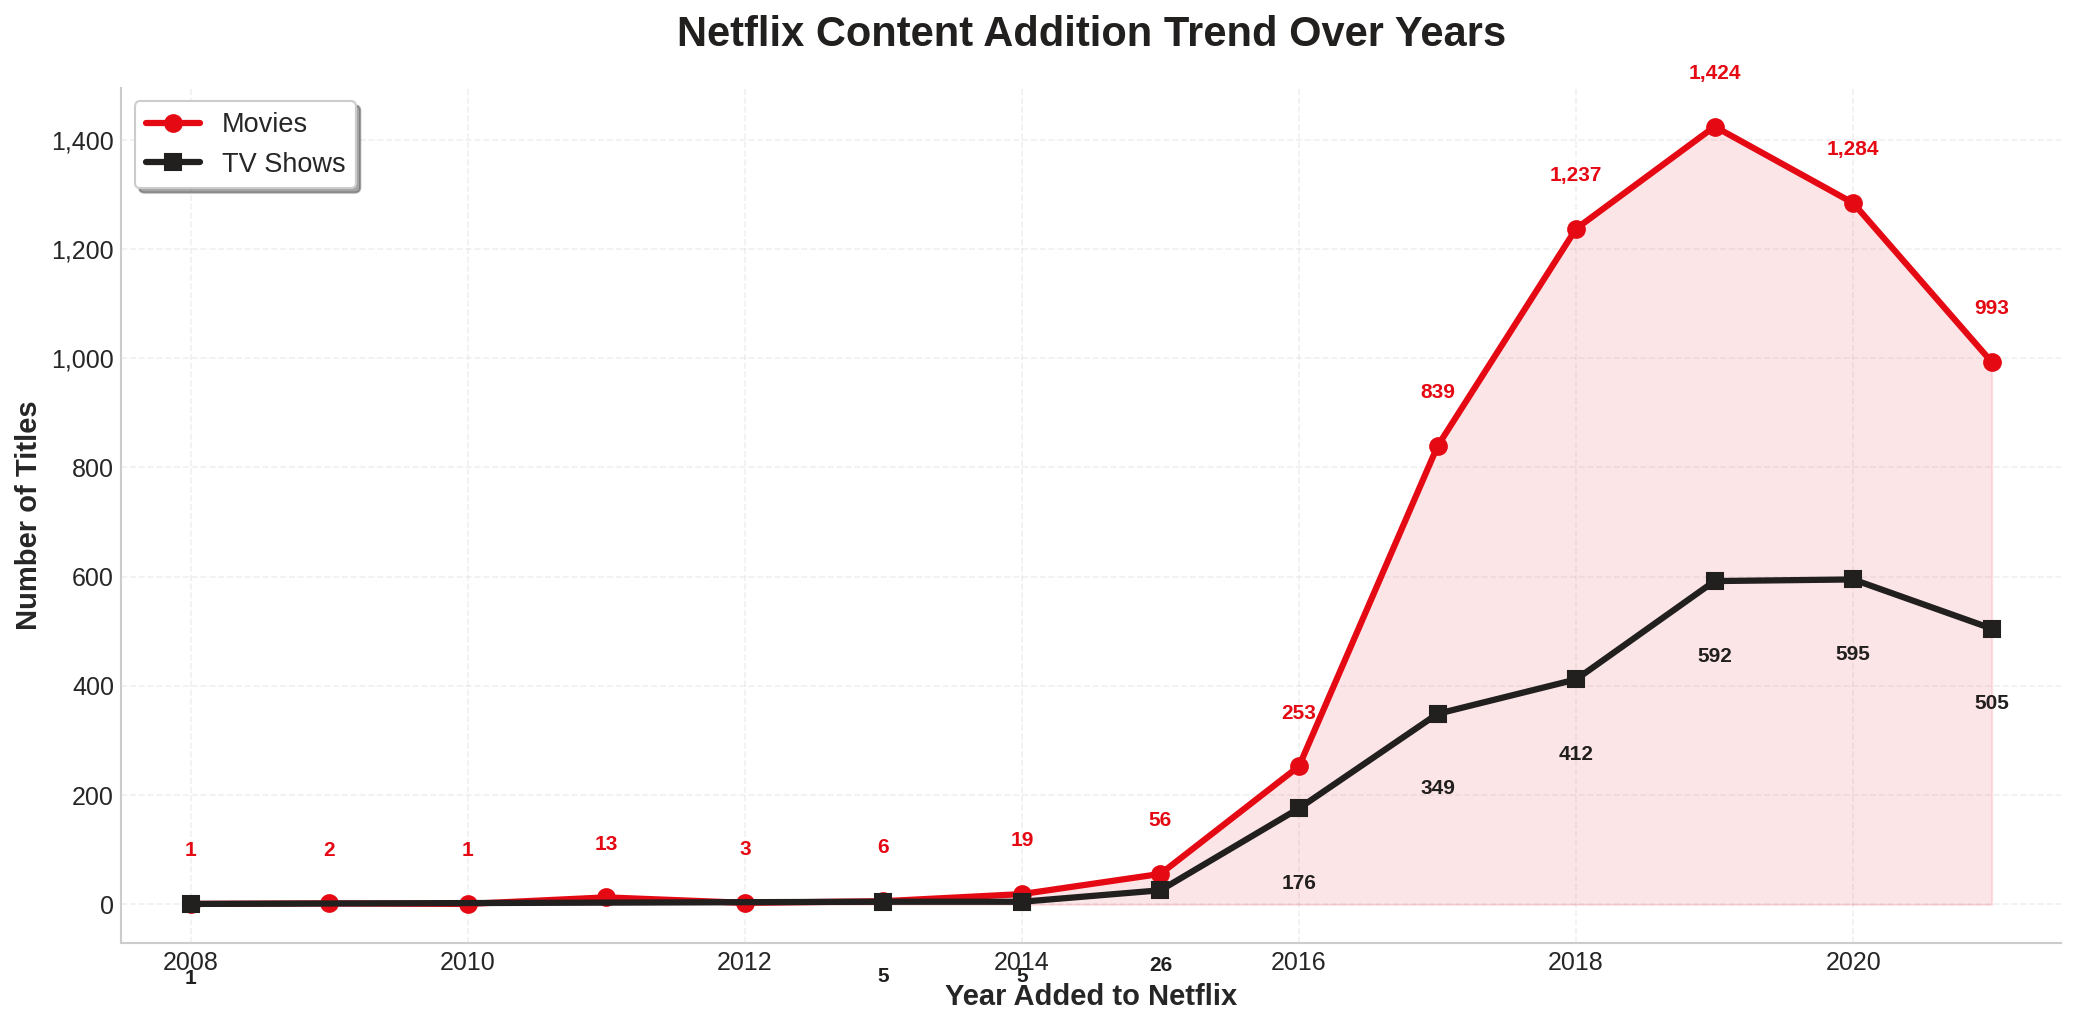


 Yearly Addition Summary:
   2019 → 2,016 titles
   2020 → 1,879 titles
   2018 → 1,649 titles
   2021 → 1,498 titles
   2017 → 1,188 titles
   2016 → 429 titles
   2015 → 82 titles
   2014 → 24 titles
   2011 → 13 titles
   2013 → 11 titles


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Count titles added per year by type
yearly_data = df_clean.groupby(['year_added', 'type']).size().reset_index(name='count')

# Separate movies and TV shows
movies_yearly = yearly_data[yearly_data['type'] == 'Movie']
tv_yearly = yearly_data[yearly_data['type'] == 'TV Show']

# Plot lines
ax.plot(movies_yearly['year_added'], movies_yearly['count'],
        color=NETFLIX_RED, linewidth=3, marker='o', markersize=8,
        label='Movies', zorder=5)

ax.plot(tv_yearly['year_added'], tv_yearly['count'],
        color=NETFLIX_BLACK, linewidth=3, marker='s', markersize=8,
        label='TV Shows', zorder=5)

# Add value labels on each point
for x, y in zip(movies_yearly['year_added'], movies_yearly['count']):
    ax.text(x, y + 80, f'{y:,}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=NETFLIX_RED)

for x, y in zip(tv_yearly['year_added'], tv_yearly['count']):
    ax.text(x, y - 120, f'{y:,}', ha='center', va='top', fontsize=10, fontweight='bold', color=NETFLIX_BLACK)

# Styling
ax.set_title('Netflix Content Addition Trend Over Years', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Year Added to Netflix', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Titles', fontsize=14, fontweight='bold')
ax.legend(fontsize=13, loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlim(movies_yearly['year_added'].min() - 0.5, movies_yearly['year_added'].max() + 0.5)

# Add shaded area under movies line for visual appeal
ax.fill_between(movies_yearly['year_added'], movies_yearly['count'], alpha=0.1, color=NETFLIX_RED)

plt.tight_layout()
plt.savefig('03_yearly_trend.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



# Print yearly summary
print(f"\n Yearly Addition Summary:")
yearly_total = df_clean.groupby('year_added').size().sort_values(ascending=False)
for year, count in yearly_total.head(10).items():
    print(f"   {year} → {count:,} titles")


# 9.2: MONTHLY CONTENT ADDITION PATTERN

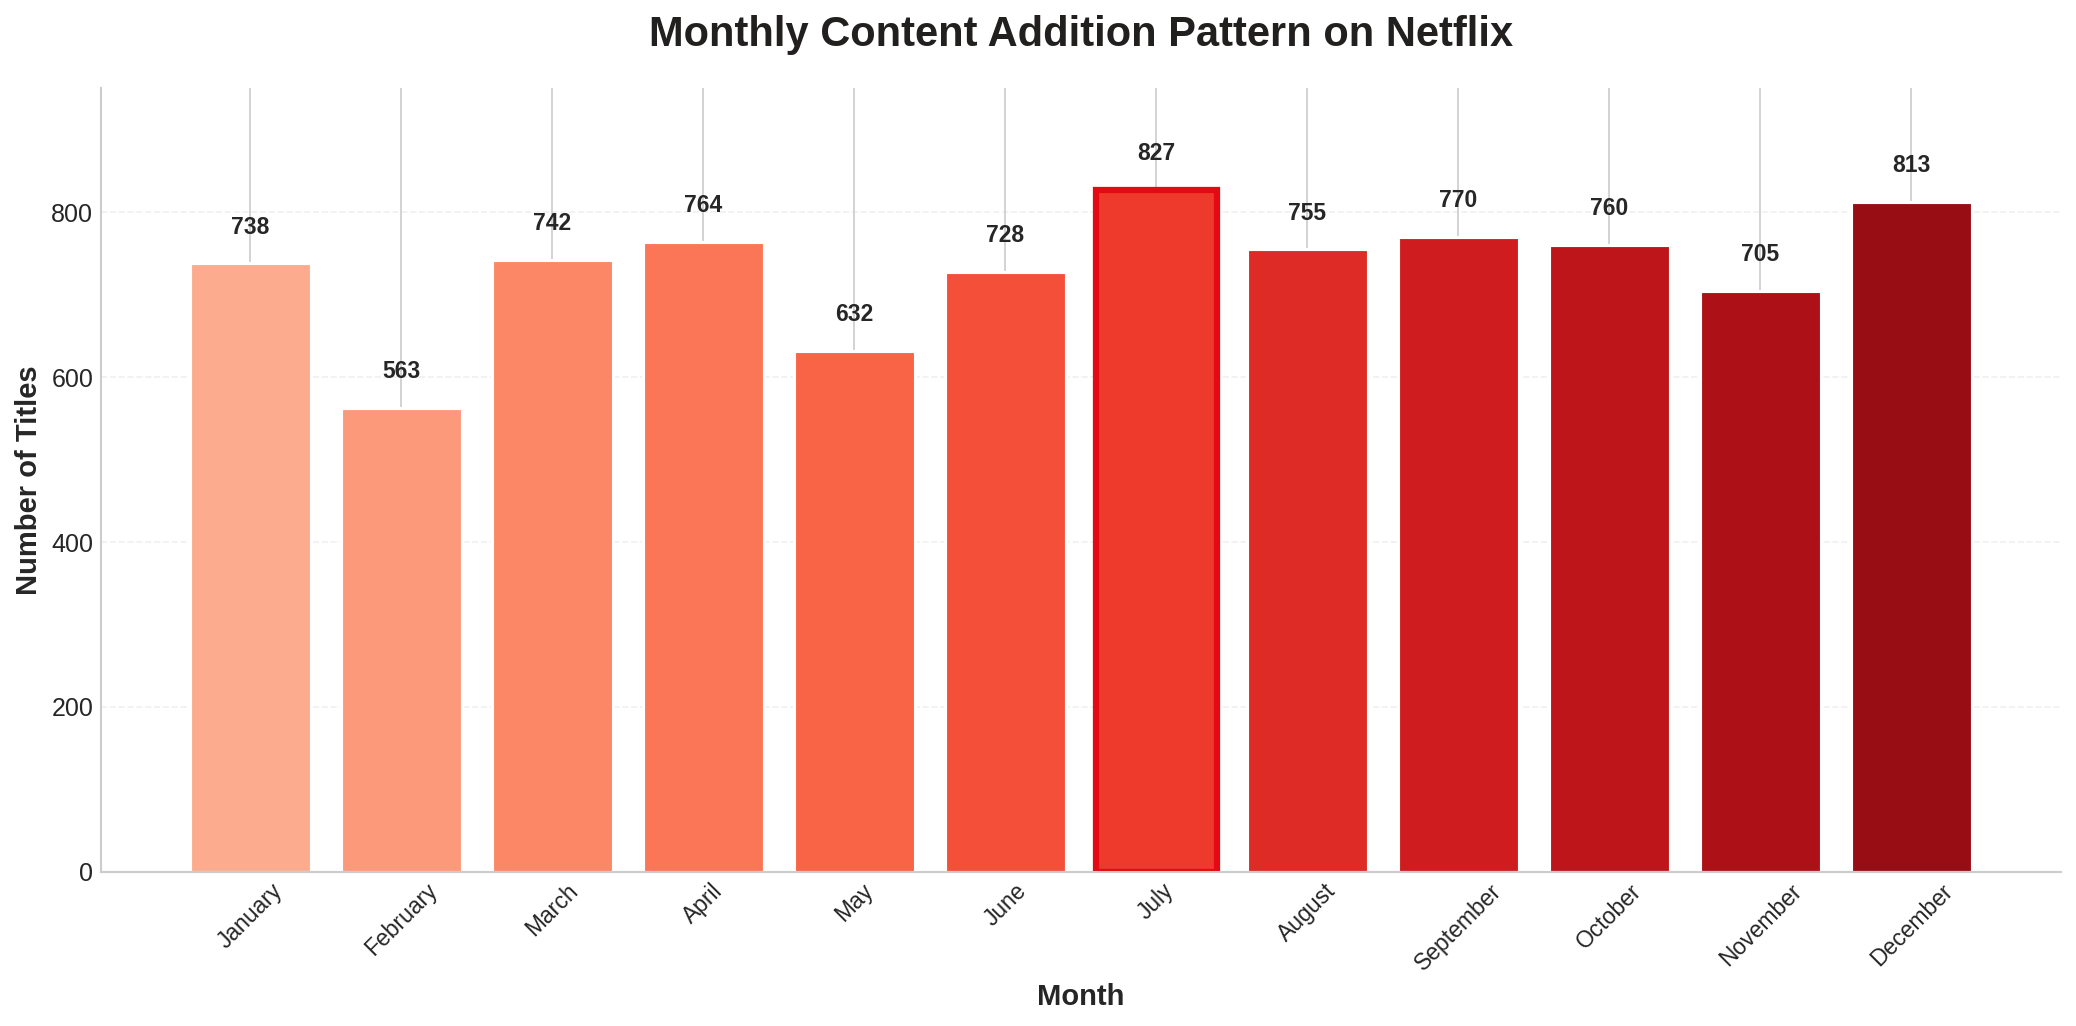


 Busiest month: July (827 titles)
 Slowest month: February (563 titles)


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Define month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_counts = df_clean.groupby('month_name').size().reindex(month_order)

colors = plt.cm.Reds(np.linspace(0.3, 0.9, 12))

bars = ax.bar(monthly_counts.index, monthly_counts.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, monthly_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlight max month
max_month = monthly_counts.idxmax()
max_idx = month_order.index(max_month)
bars[max_idx].set_edgecolor(NETFLIX_RED)
bars[max_idx].set_linewidth(3)

ax.set_title('Monthly Content Addition Pattern on Netflix', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Titles', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=11, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_ylim(0, max(monthly_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('03b_monthly_pattern.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Busiest month: {monthly_counts.idxmax()} ({monthly_counts.max():,} titles)")
print(f" Slowest month: {monthly_counts.idxmin()} ({monthly_counts.min():,} titles)")

#10: VISUALIZATION 4: Top 10 Genres on Netflix

#10.1: TOP 10 GENRES ON NETFLIX — BAR CHART

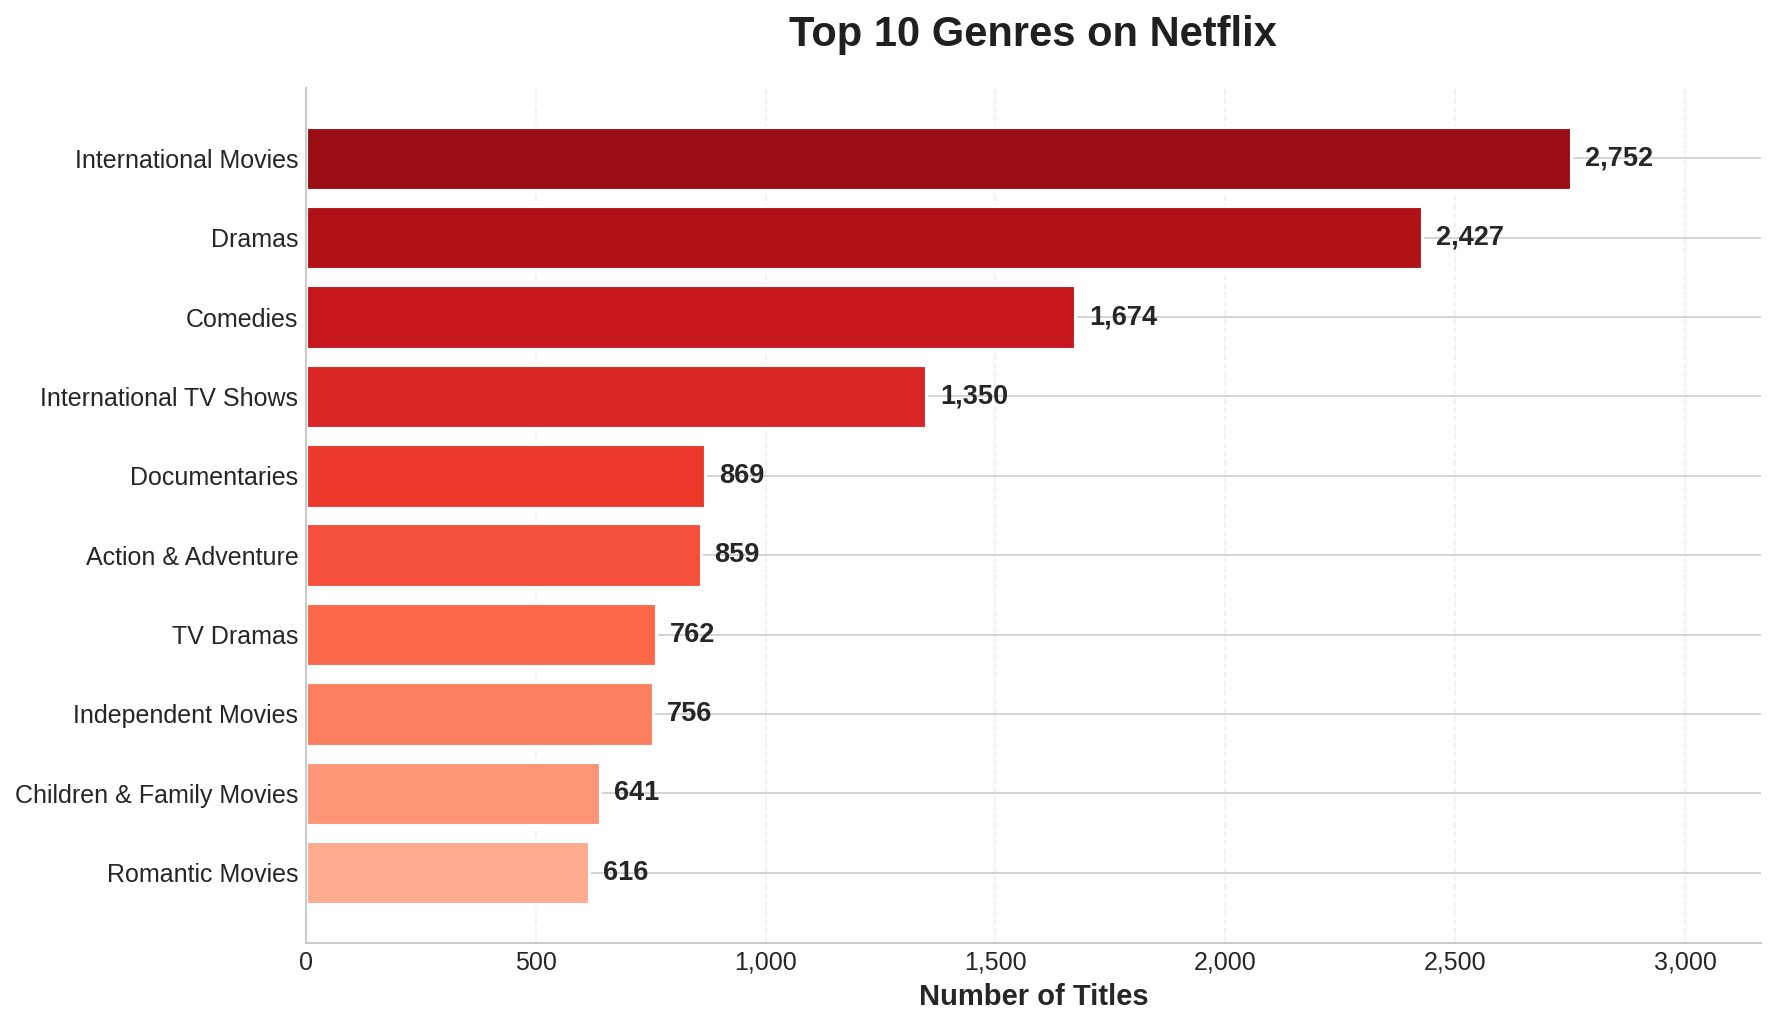


 Top 10 Genres:
    1. International Movies                → 2,752 titles
    2. Dramas                              → 2,427 titles
    3. Comedies                            → 1,674 titles
    4. International TV Shows              → 1,350 titles
    5. Documentaries                       → 869 titles
    6. Action & Adventure                  → 859 titles
    7. TV Dramas                           → 762 titles
    8. Independent Movies                  → 756 titles
    9. Children & Family Movies            → 641 titles
   10. Romantic Movies                     → 616 titles


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Split genres and count each individually
all_genres = df_clean['listed_in'].dropna().str.split(', ')
genres_exploded = all_genres.explode()
genre_counts = genres_exploded.value_counts().head(10)

# Sort for horizontal bar (highest at top)
genre_counts = genre_counts.sort_values(ascending=True)

# Create color gradient
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(genre_counts)))

bars = ax.barh(genre_counts.index, genre_counts.values, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, count in zip(bars, genre_counts.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{count:,}', ha='left', va='center', fontsize=13, fontweight='bold')

ax.set_title('Top 10 Genres on Netflix', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Number of Titles', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_xlim(0, max(genre_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('04_top_genres.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Top 10 Genres:")
for i, (genre, count) in enumerate(genre_counts.sort_values(ascending=False).items(), 1):
    print(f"   {i:2d}. {genre:<35s} → {count:,} titles")

#10.2: TOP 10 GENRES COMPARISON — MOVIES VS TV SHOWS

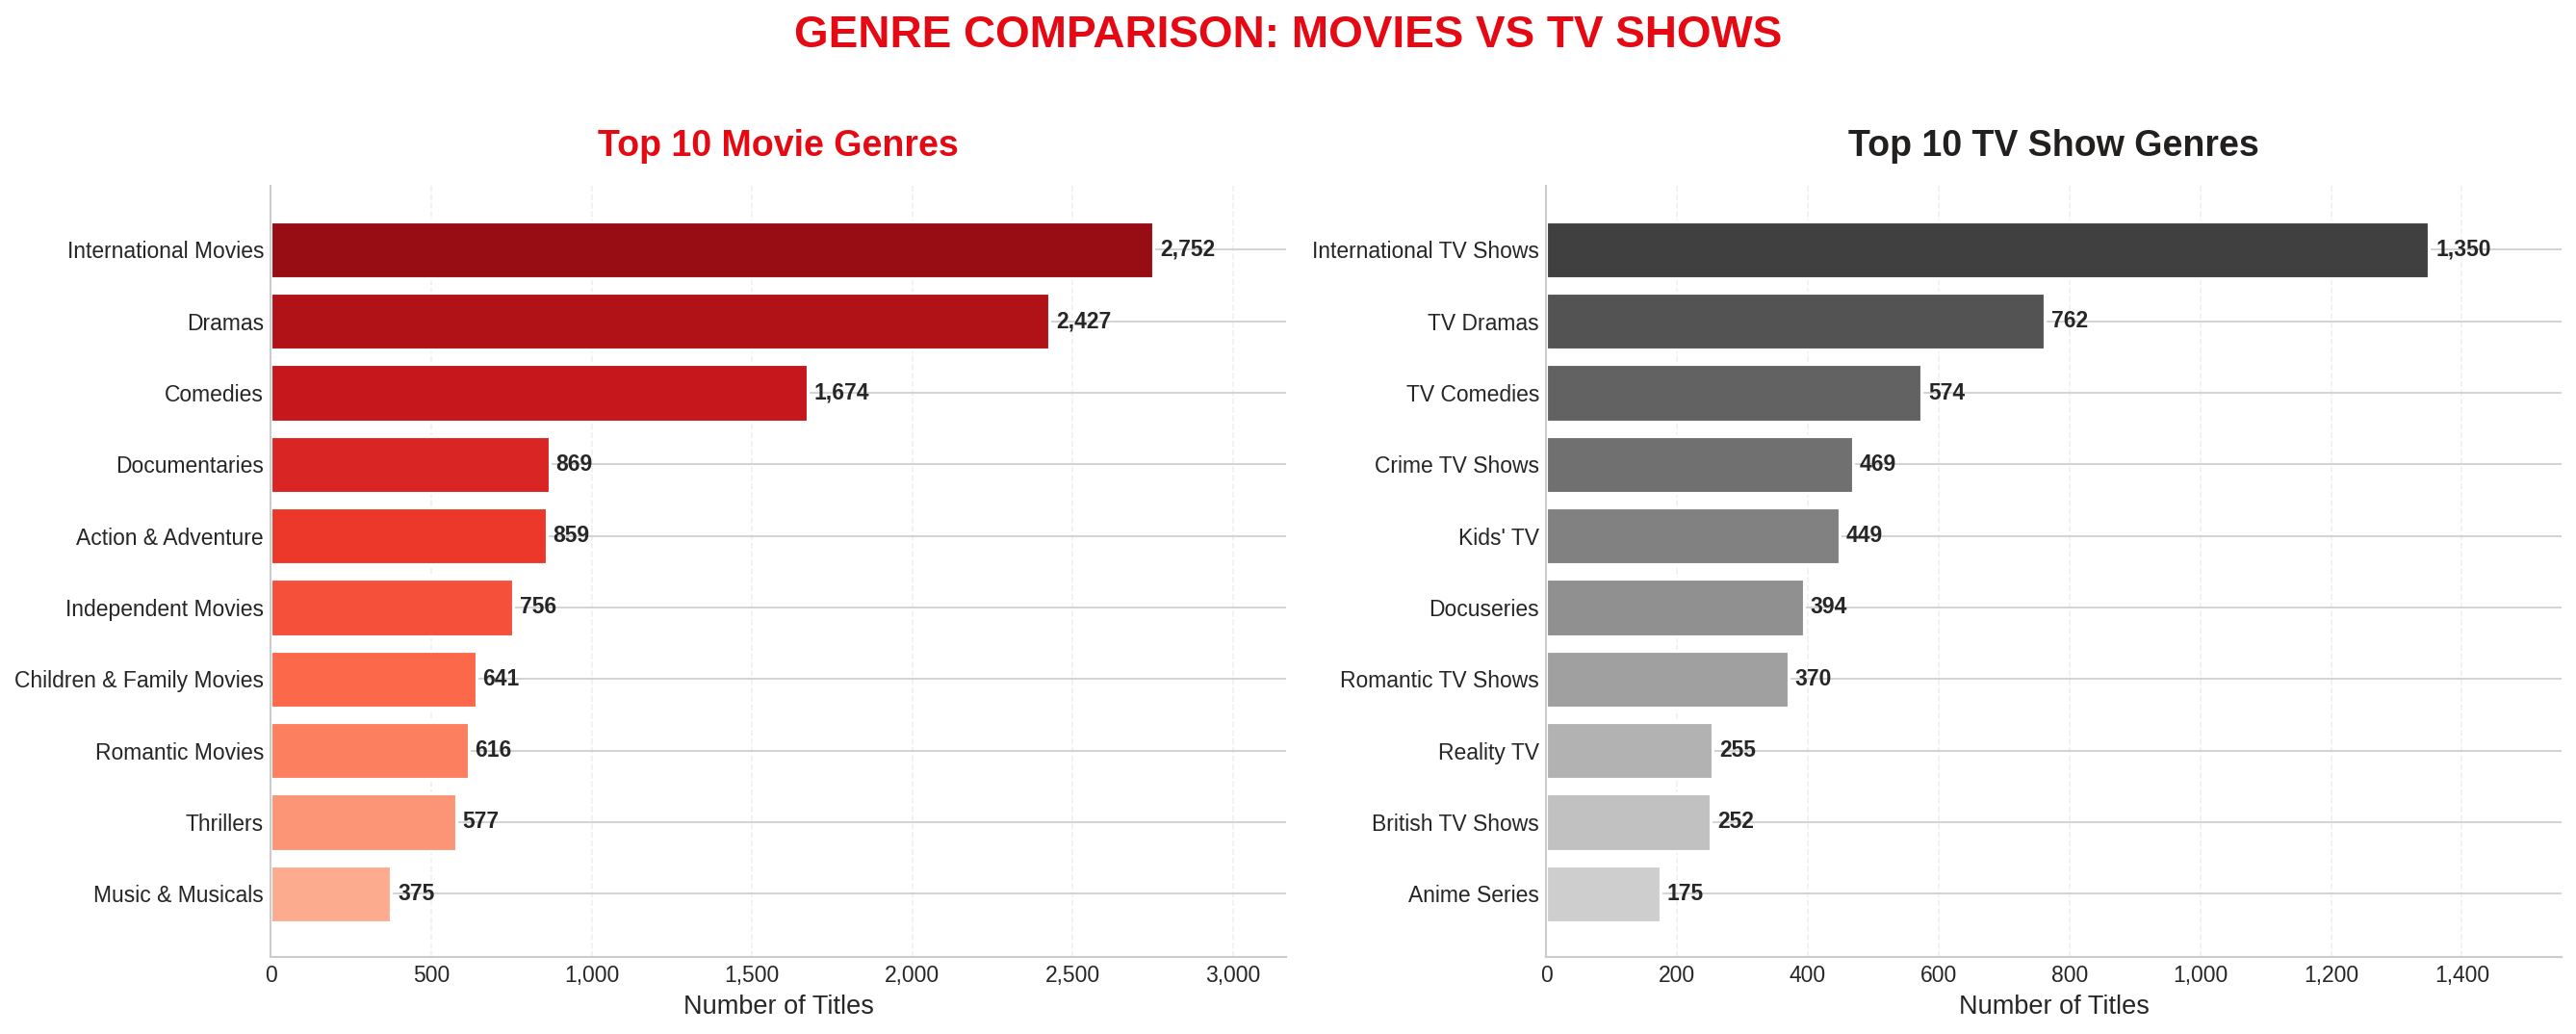

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Movies Genres ---
movies = df_clean[df_clean['type'] == 'Movie']
movie_genres = movies['listed_in'].dropna().str.split(', ').explode()
movie_genre_counts = movie_genre_counts = movie_genres.value_counts().head(10).sort_values(ascending=True)

colors_movies = plt.cm.Reds(np.linspace(0.3, 0.9, len(movie_genre_counts)))

bars1 = axes[0].barh(movie_genre_counts.index, movie_genre_counts.values, color=colors_movies, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars1, movie_genre_counts.values):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', ha='left', va='center', fontsize=11, fontweight='bold')

axes[0].set_title('Top 10 Movie Genres', fontsize=18, fontweight='bold', pad=15, color=NETFLIX_RED)
axes[0].set_xlabel('Number of Titles', fontsize=13)
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', labelsize=11)
axes[0].tick_params(axis='y', labelsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
axes[0].set_xlim(0, max(movie_genre_counts.values) * 1.15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].xaxis.grid(True, linestyle='--', alpha=0.3)

# --- TV Shows Genres ---
tv = df_clean[df_clean['type'] == 'TV Show']
tv_genres = tv['listed_in'].dropna().str.split(', ').explode()
tv_genre_counts = tv_genres.value_counts().head(10).sort_values(ascending=True)

colors_tv = plt.cm.Greys(np.linspace(0.3, 0.8, len(tv_genre_counts)))

bars2 = axes[1].barh(tv_genre_counts.index, tv_genre_counts.values, color=colors_tv, edgecolor='white', linewidth=1.5)

for bar, count in zip(bars2, tv_genre_counts.values):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', ha='left', va='center', fontsize=11, fontweight='bold')

axes[1].set_title('Top 10 TV Show Genres', fontsize=18, fontweight='bold', pad=15, color=NETFLIX_BLACK)
axes[1].set_xlabel('Number of Titles', fontsize=13)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', labelsize=11)
axes[1].tick_params(axis='y', labelsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
axes[1].set_xlim(0, max(tv_genre_counts.values) * 1.15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].xaxis.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('GENRE COMPARISON: MOVIES VS TV SHOWS',
             fontsize=22, fontweight='bold', color=NETFLIX_RED, y=1.02)

plt.tight_layout()
plt.savefig('04b_genre_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#11: VISUALIZATION 5: Content Rating Distribution

#11.1 CONTENT RATING DISTRIBUTION — BAR CHART

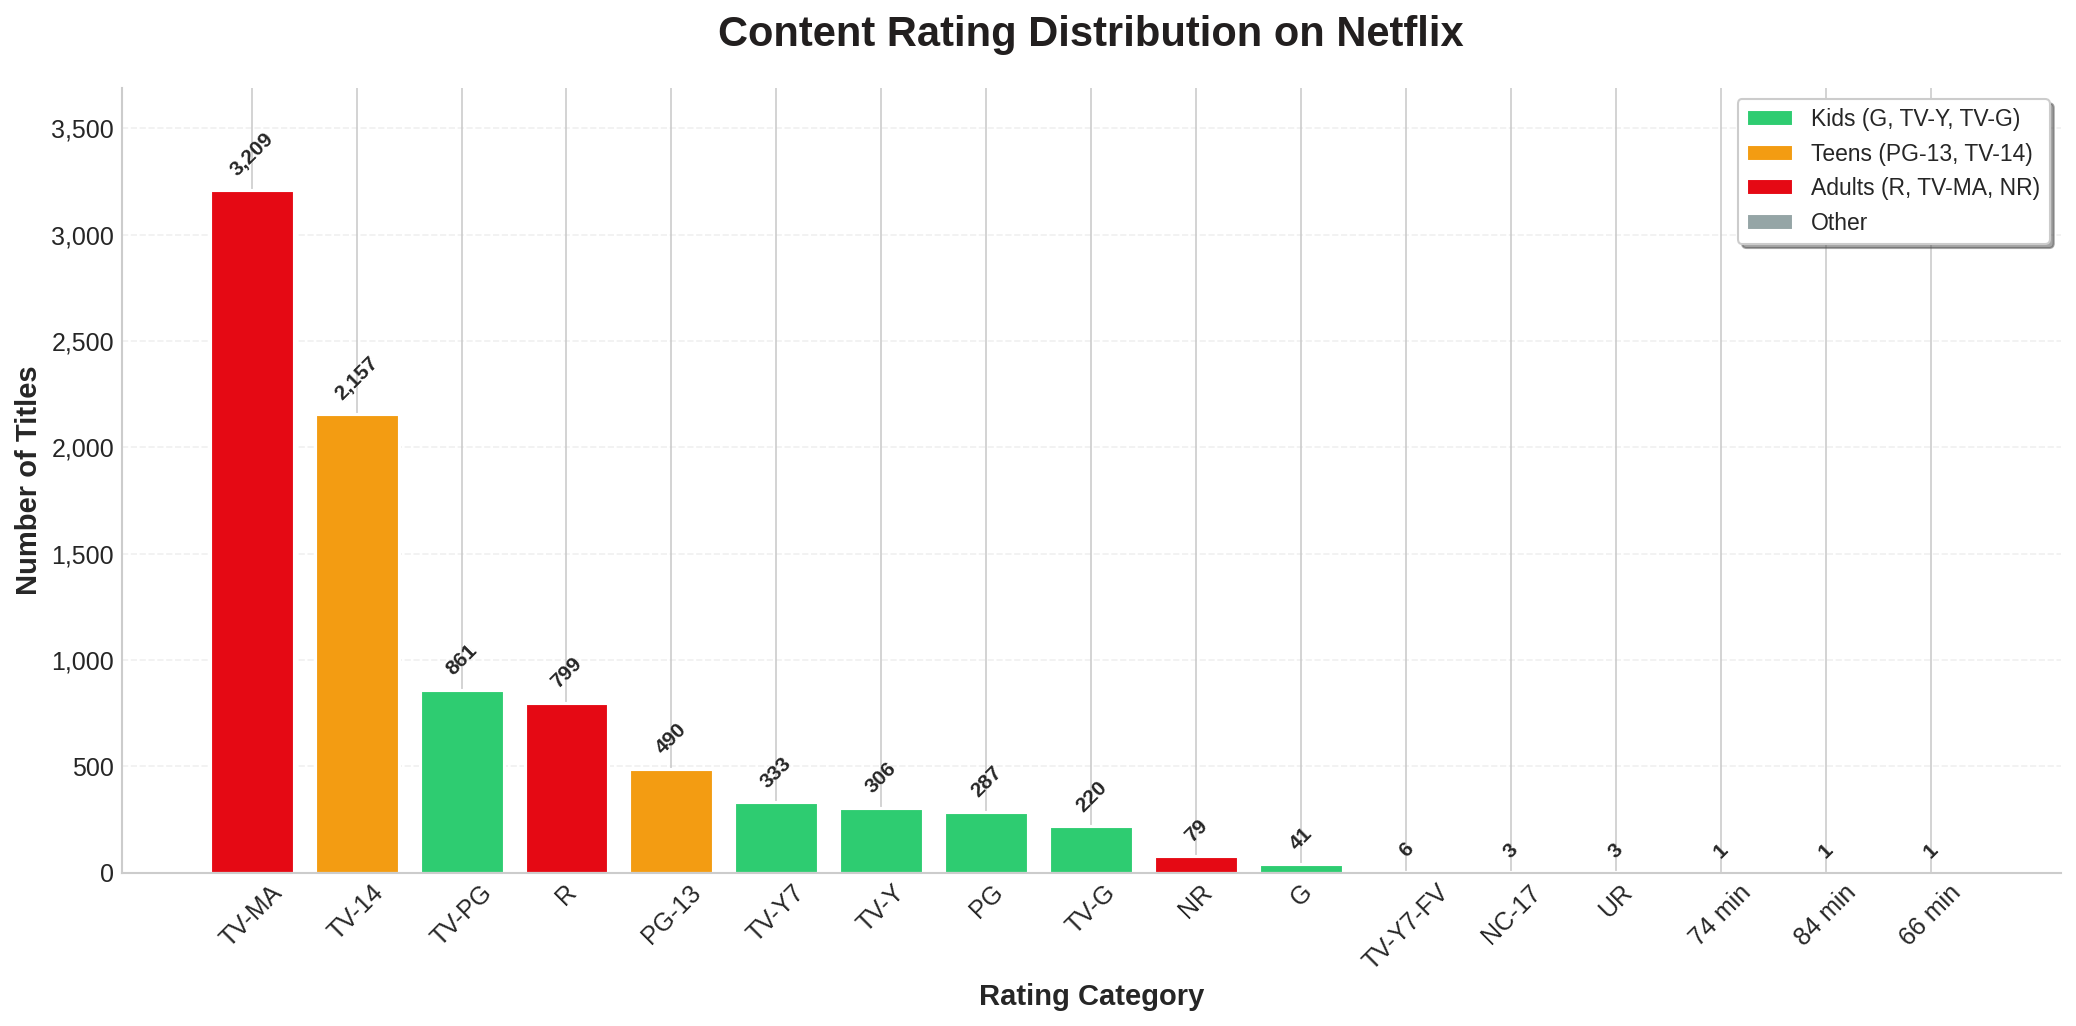


 Rating Distribution:
    1. TV-MA      → 3,209 titles
    2. TV-14      → 2,157 titles
    3. TV-PG      → 861 titles
    4. R          → 799 titles
    5. PG-13      → 490 titles
    6. TV-Y7      → 333 titles
    7. TV-Y       → 306 titles
    8. PG         → 287 titles
    9. TV-G       → 220 titles
   10. NR         → 79 titles
   11. G          → 41 titles
   12. TV-Y7-FV   → 6 titles
   13. NC-17      → 3 titles
   14. UR         → 3 titles
   15. 74 min     → 1 titles
   16. 84 min     → 1 titles
   17. 66 min     → 1 titles


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Count ratings and sort
rating_counts = df_clean['rating'].value_counts().sort_values(ascending=False)

# Define color groups
# Audience categories
kids_ratings = ['TV-Y', 'TV-Y7', 'TV-G', 'G', 'TV-Y7-FV', 'PG', 'TV-PG']
teen_ratings = ['PG-13', 'TV-14']
adult_ratings = ['R', 'TV-MA', 'NC-17', 'NR', 'UR']
other_ratings = ['TV-Y7-FV', '74 min', '84 min', '66 min']

colors = []
for rating in rating_counts.index:
    if rating in kids_ratings:
        colors.append('#2ECC71')   # Green for kids
    elif rating in teen_ratings:
        colors.append('#F39C12')   # Orange for teens
    elif rating in adult_ratings:
        colors.append(NETFLIX_RED) # Red for adults
    else:
        colors.append('#95A5A6')   # Grey for others

bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, count in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=45)

ax.set_title('Content Rating Distribution on Netflix', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Rating Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Titles', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_ylim(0, max(rating_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ECC71', edgecolor='white', label='Kids (G, TV-Y, TV-G)'),
    Patch(facecolor='#F39C12', edgecolor='white', label='Teens (PG-13, TV-14)'),
    Patch(facecolor=NETFLIX_RED, edgecolor='white', label='Adults (R, TV-MA, NR)'),
    Patch(facecolor='#95A5A6', edgecolor='white', label='Other')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig('05_rating_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n Rating Distribution:")
for i, (rating, count) in enumerate(rating_counts.items(), 1):
    print(f"   {i:2d}. {rating:<10s} → {count:,} titles")

#11.2: RATING DISTRIBUTION BY TYPE — GROUPED BAR CHART

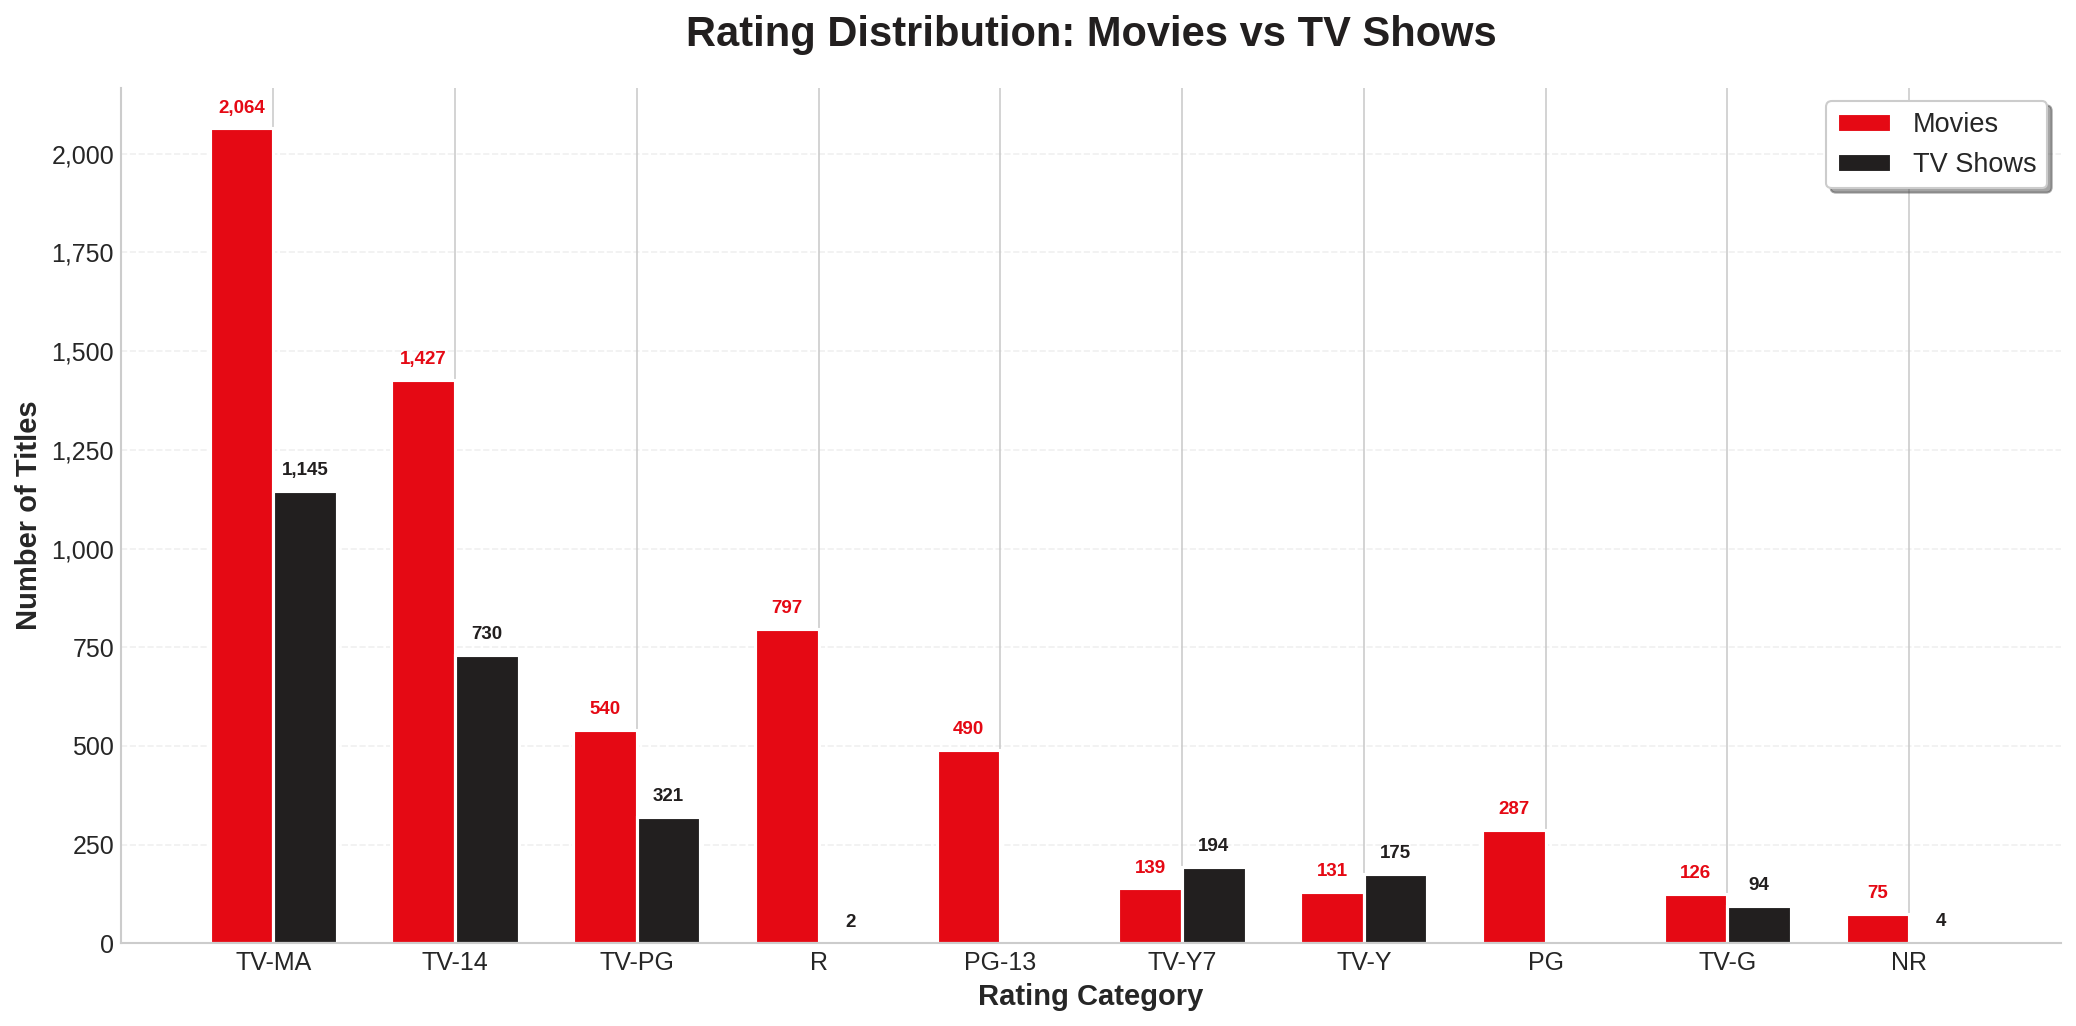

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Get top 10 most common ratings
top_ratings = df_clean['rating'].value_counts().head(10).index.tolist()

# Filter data for top ratings only
df_top_ratings = df_clean[df_clean['rating'].isin(top_ratings)]

# Create grouped data
rating_by_type = df_top_ratings.groupby(['rating', 'type']).size().unstack(fill_value=0)
rating_by_type = rating_by_type.reindex(top_ratings)

# Plot grouped bar chart
x = np.arange(len(top_ratings))
width = 0.35

bars_movies = ax.bar(x - width/2, rating_by_type['Movie'], width,
                     color=NETFLIX_RED, edgecolor='white', linewidth=1.5, label='Movies')

bars_tv = ax.bar(x + width/2, rating_by_type['TV Show'], width,
                 color=NETFLIX_BLACK, edgecolor='white', linewidth=1.5, label='TV Shows')

# Add value labels on bars
for bar in bars_movies:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 30,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=NETFLIX_RED)

for bar in bars_tv:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, height + 30,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=NETFLIX_BLACK)

ax.set_title('Rating Distribution: Movies vs TV Shows', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Rating Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Titles', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_ratings, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.legend(fontsize=13, loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('05b_rating_by_type.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


#12: VISUALIZATION 6: Movie Duration Analysis

#12.1: MOVIE DURATION DISTRIBUTION — HISTOGRAM

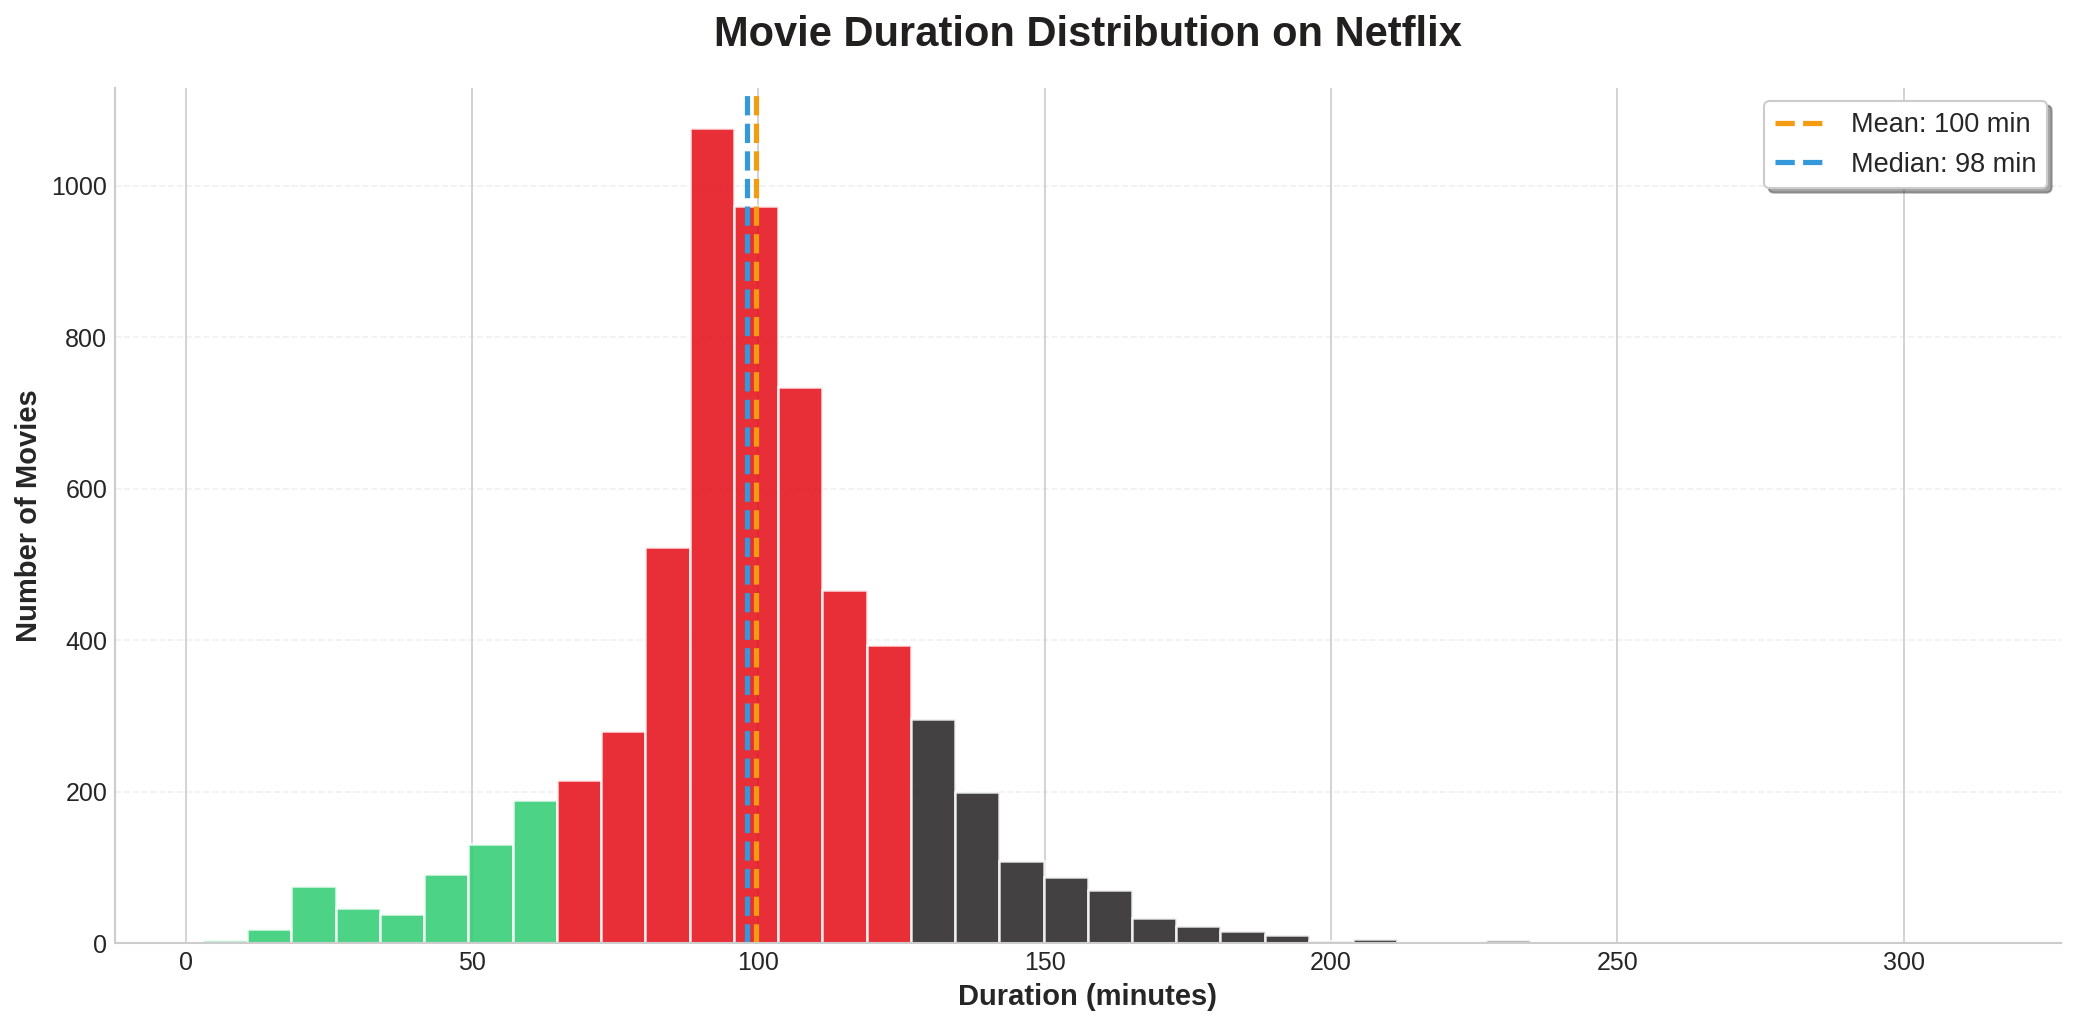


📊 Movie Duration Statistics:
   Mean Duration   : 100 minutes
   Median Duration : 98 minutes
   Shortest Movie  : 3.0 minutes
   Longest Movie   : 312.0 minutes
   Std Deviation   : 28 minutes


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Filter movies only (excluding unknown duration)
movies_duration = df_clean[(df_clean['type'] == 'Movie') & (df_clean['duration_numeric'] > 0)]['duration_numeric']

# Histogram
counts, bins, patches = ax.hist(movies_duration, bins=40, color=NETFLIX_RED, edgecolor='white', linewidth=1.2, alpha=0.85)

# Color bars based on duration categories
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < 60:
        patch.set_facecolor('#2ECC71')    # Green: Short (<60 min)
    elif left_edge < 120:
        patch.set_facecolor(NETFLIX_RED)  # Red: Medium (60-120 min)
    else:
        patch.set_facecolor(NETFLIX_BLACK) # Black: Long (>120 min)

# Add mean and median lines
mean_duration = movies_duration.mean()
median_duration = movies_duration.median()

ax.axvline(mean_duration, color='#F39C12', linewidth=2.5, linestyle='--', label=f'Mean: {mean_duration:.0f} min')
ax.axvline(median_duration, color='#3498DB', linewidth=2.5, linestyle='--', label=f'Median: {median_duration:.0f} min')

ax.set_title('Movie Duration Distribution on Netflix', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Duration (minutes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Movies', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=13, loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('06_movie_duration.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Movie Duration Statistics:")
print(f"   Mean Duration   : {mean_duration:.0f} minutes")
print(f"   Median Duration : {median_duration:.0f} minutes")
print(f"   Shortest Movie  : {movies_duration.min()} minutes")
print(f"   Longest Movie   : {movies_duration.max()} minutes")
print(f"   Std Deviation   : {movies_duration.std():.0f} minutes")

#12.2: TV SHOW SEASONS DISTRIBUTION — BAR CHART

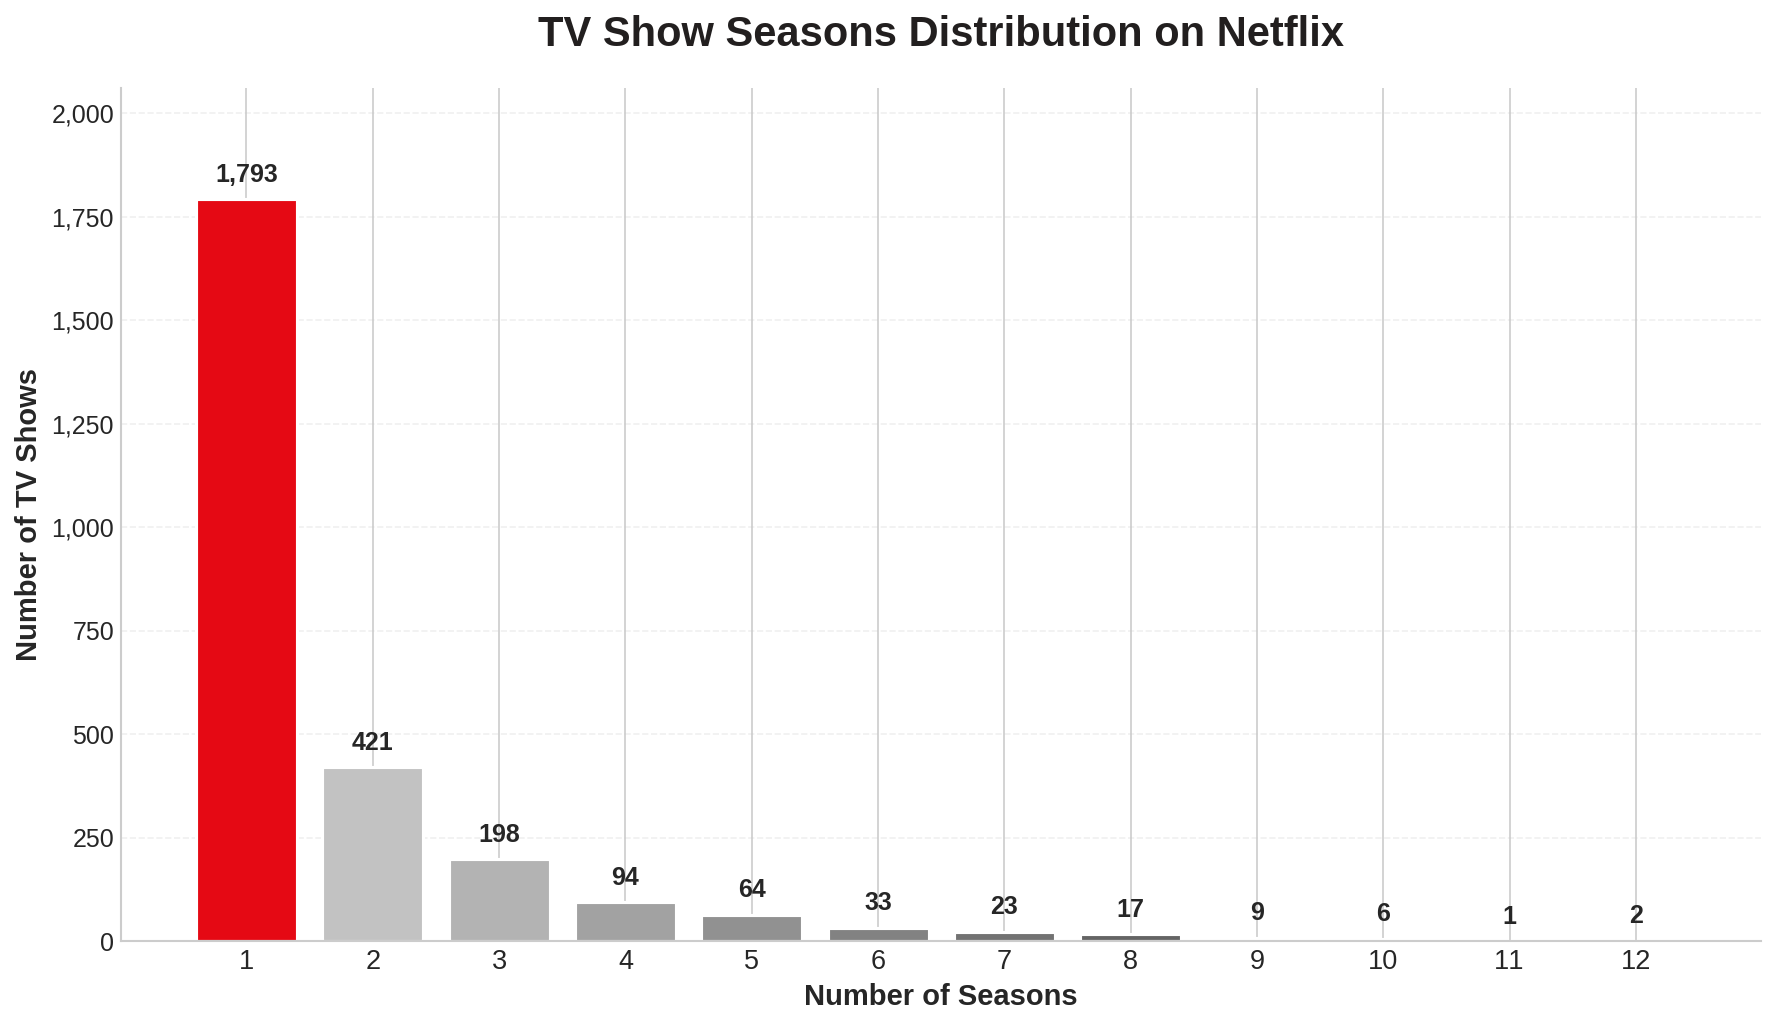


📊 TV Show Duration Statistics:
   Average Seasons : 1.8
   Max Seasons     : 17.0
   Most Common     : 1.0 season(s) (1,793 shows)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Filter TV shows only
tv_seasons = df_clean[(df_clean['type'] == 'TV Show') & (df_clean['duration_numeric'] > 0)]['duration_numeric']
season_counts = tv_seasons.value_counts().sort_index()

# Limit to top 12 seasons for readability
season_counts = season_counts.head(12)

# Create color gradient
colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(season_counts)))

bars = ax.bar(season_counts.index.astype(int).astype(str), season_counts.values,
              color=colors, edgecolor='white', linewidth=1.5)

# Highlight season 1
bars[0].set_facecolor(NETFLIX_RED)

# Add value labels
for bar, count in zip(bars, season_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('TV Show Seasons Distribution on Netflix', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Number of Seasons', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of TV Shows', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_ylim(0, max(season_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('06b_tv_seasons.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 TV Show Duration Statistics:")
print(f"   Average Seasons : {tv_seasons.mean():.1f}")
print(f"   Max Seasons     : {tv_seasons.max()}")
print(f"   Most Common     : {season_counts.idxmax()} season(s) ({season_counts.max():,} shows)")

#13:VISUALIZATION 7: Content Addition Heatmap (Year vs Month)

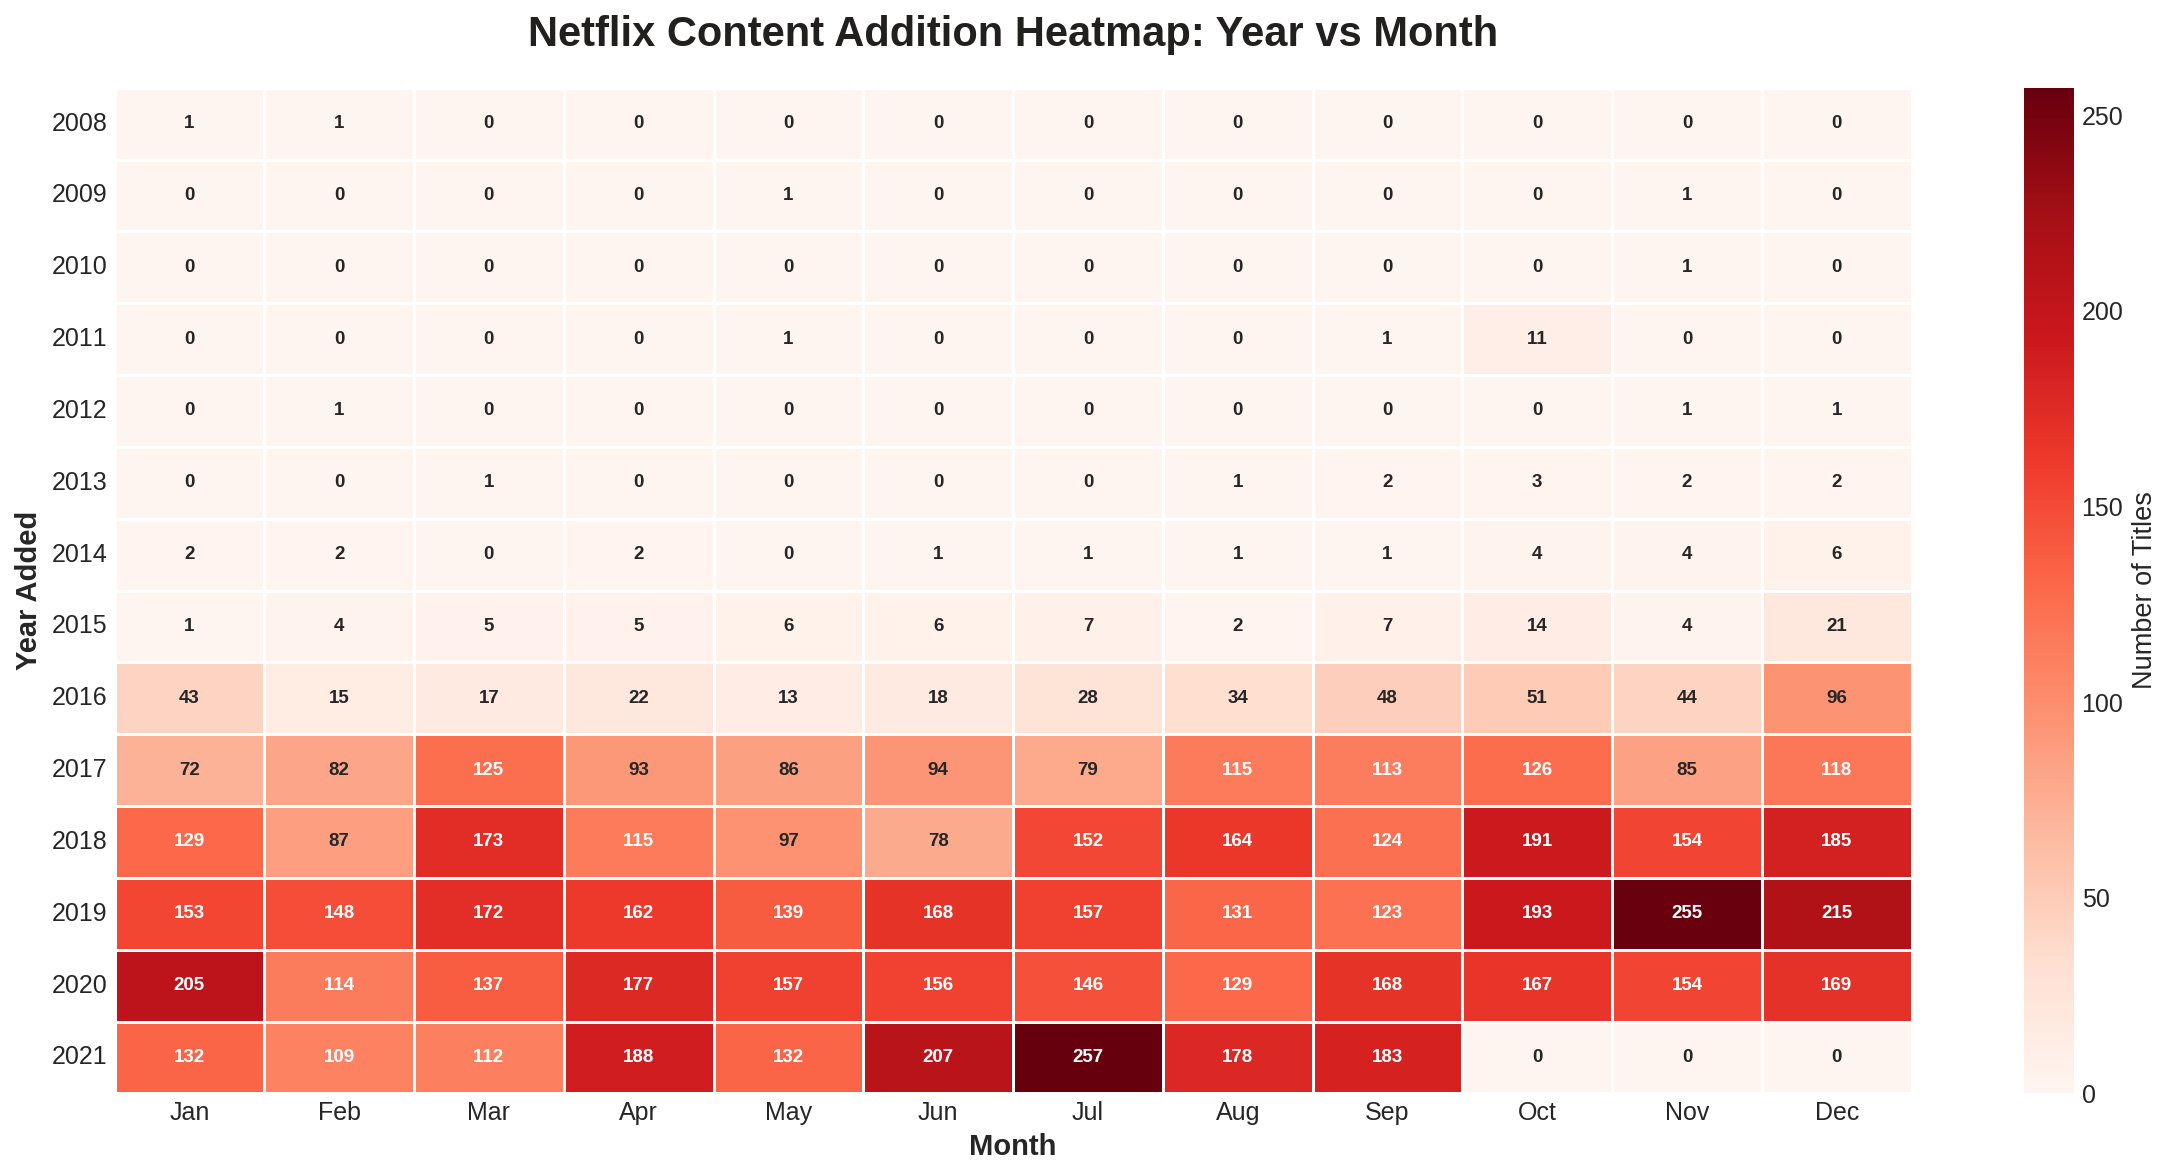


 Peak Addition Period:
   Jul 2021 → 257 titles


In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

# Create pivot table for heatmap
heatmap_data = df_clean.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)

# Define month names for better readability
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.columns = month_names

# Create heatmap
sns.heatmap(heatmap_data,
            cmap='Reds',
            annot=True,
            fmt='d',
            cbar_kws={'label': 'Number of Titles'},
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            annot_kws={'fontsize': 9, 'fontweight': 'bold'})

ax.set_title('Netflix Content Addition Heatmap: Year vs Month',
             fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Year Added', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Rotate y-axis labels for better readability
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('07_monthly_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


print(f"\n Peak Addition Period:")
# Find the year-month combination with max additions
max_idx = heatmap_data.stack().idxmax()
max_year, max_month_num = max_idx
max_count = heatmap_data.stack().max()
print(f"   {max_month_num} {max_year} → {max_count:,} titles")

#14: VISUALIZATION 8: Top Directors on Netflix

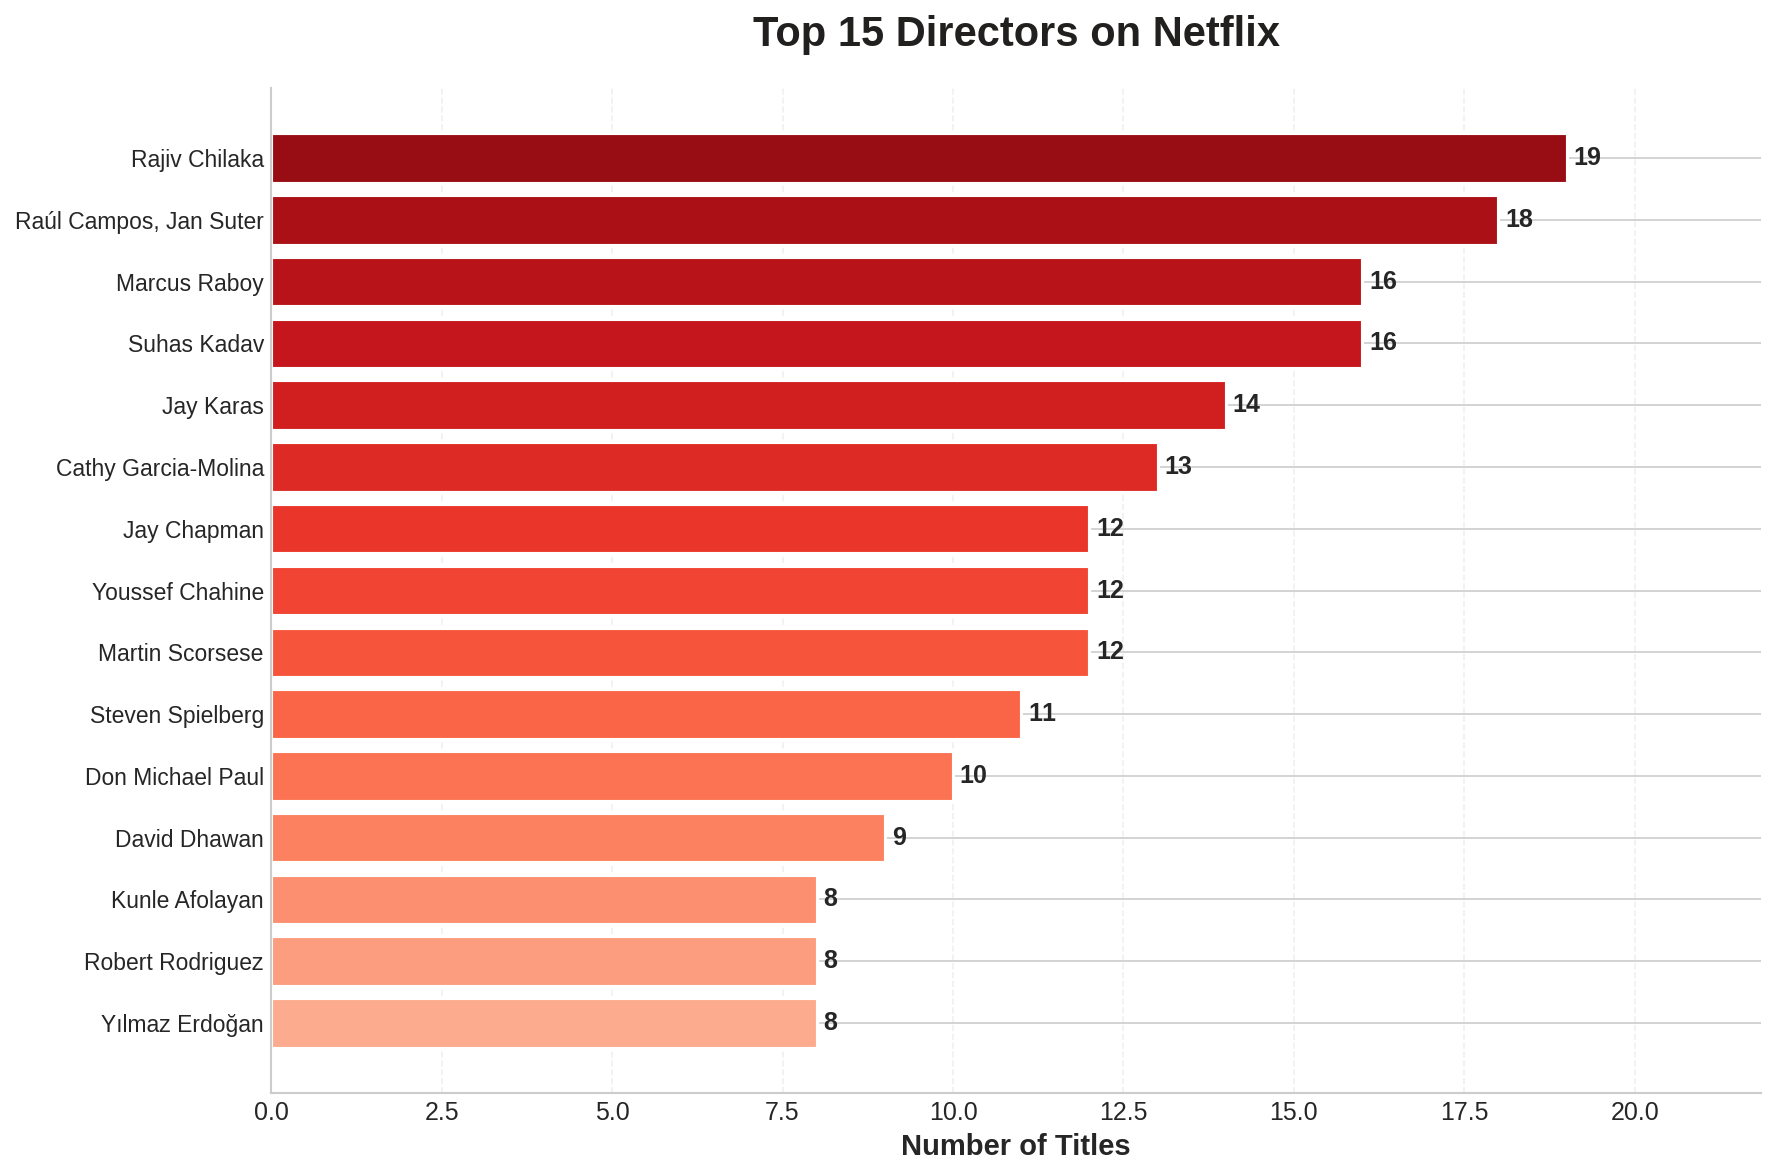


📊 Top 15 Directors:
    1. Rajiv Chilaka                       → 19 title(s)
    2. Raúl Campos, Jan Suter              → 18 title(s)
    3. Suhas Kadav                         → 16 title(s)
    4. Marcus Raboy                        → 16 title(s)
    5. Jay Karas                           → 14 title(s)
    6. Cathy Garcia-Molina                 → 13 title(s)
    7. Martin Scorsese                     → 12 title(s)
    8. Youssef Chahine                     → 12 title(s)
    9. Jay Chapman                         → 12 title(s)
   10. Steven Spielberg                    → 11 title(s)
   11. Don Michael Paul                    → 10 title(s)
   12. David Dhawan                        → 9 title(s)
   13. Robert Rodriguez                    → 8 title(s)
   14. Kunle Afolayan                      → 8 title(s)
   15. Yılmaz Erdoğan                      → 8 title(s)


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Count directors (excluding 'Unknown')
director_counts = df_clean[df_clean['director'] != 'Unknown']['director'].value_counts().head(15)

# Sort for horizontal bar chart
director_counts = director_counts.sort_values(ascending=True)

# Create color gradient
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(director_counts)))

bars = ax.barh(director_counts.index, director_counts.values, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels
for bar, count in zip(bars, director_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{count}', ha='left', va='center', fontsize=12, fontweight='bold')

ax.set_title('Top 15 Directors on Netflix', fontsize=20, fontweight='bold', pad=20, color=NETFLIX_BLACK)
ax.set_xlabel('Number of Titles', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.set_xlim(0, max(director_counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('08_top_directors.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n📊 Top 15 Directors:")
for i, (director, count) in enumerate(director_counts.sort_values(ascending=False).items(), 1):
    print(f"   {i:2d}. {director:<35s} → {count} title(s)")